In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 1000
X0 = np.random.randn(n_samples // 2,2) + np.array([-2,-2])
X1 = np.random.randn(n_samples // 2,2) + np.array([2,2])
X = np.vstack([X0,X1])
y = np.hstack([np.zeros(n_samples // 2),np.ones(n_samples // 2)]).astype(int)

indices = np.arange(n_samples)
np.random.shuffle(indices)
X,y = X[indices],y[indices]

df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'label':y})
df.to_csv('data.csv',index=False)
print('已生成data.csv,前5行如下:')
print(df.head())

class CSVDataset(Dataset):
    def __init__(self,csv_file):
        df = pd.read_csv(csv_file)
        self.features = df[['feature1','feature2']].values.astype('float32')
        self.labels = df['label'].values.astype('float32')
    def __len__(self):
        return len(self.features)
    def __getitem__(self,idx):
        x = torch.tensor(self.features[idx])
        y = torch.tensor(self.labels[idx])
        return x,y

dataset = CSVDataset('data.csv')

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset,val_dataset = torch.utils.data.random_split(dataset,[train_size,val_size])

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=False)

class LogisticRegression(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim,1)
    def forward(self,x):
        return self.linear(x)
model = LogisticRegression(input_dim=2)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(),lr=0.01)


num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    for batch_x,batch_y in train_loader:
        batch_y = batch_y.unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs,batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)
    avg_train_loss = total_loss / len(train_loader.dataset)

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
      for batch_x,batch_y in val_loader:
        outputs = model(batch_x)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds.squeeze() == batch_y).sum().item()
        total += batch_y.size(0)
    val_acc = correct / total
    print(f'Epoch {epoch+1:2d}: 训练损失 = {avg_train_loss:.4f}, 验证准确率 = {val_acc:.4f}')



已生成data.csv,前5行如下:
   feature1  feature2  label
0  3.024063  2.592527      1
1  3.661259  1.542904      1
2 -3.607483 -1.815366      0
3  3.076007  2.021312      1
4 -2.756351 -3.422254      0
Epoch  1: 训练损失 = 0.1591, 验证准确率 = 0.9950
Epoch  2: 训练损失 = 0.1354, 验证准确率 = 0.9950
Epoch  3: 训练损失 = 0.1184, 验证准确率 = 0.9950
Epoch  4: 训练损失 = 0.1058, 验证准确率 = 0.9950
Epoch  5: 训练损失 = 0.0959, 验证准确率 = 0.9950
Epoch  6: 训练损失 = 0.0880, 验证准确率 = 0.9950
Epoch  7: 训练损失 = 0.0815, 验证准确率 = 0.9950
Epoch  8: 训练损失 = 0.0760, 验证准确率 = 0.9950
Epoch  9: 训练损失 = 0.0714, 验证准确率 = 0.9950
Epoch 10: 训练损失 = 0.0674, 验证准确率 = 0.9950
Epoch 11: 训练损失 = 0.0639, 验证准确率 = 0.9950
Epoch 12: 训练损失 = 0.0608, 验证准确率 = 0.9950
Epoch 13: 训练损失 = 0.0581, 验证准确率 = 0.9950
Epoch 14: 训练损失 = 0.0557, 验证准确率 = 0.9950
Epoch 15: 训练损失 = 0.0535, 验证准确率 = 0.9950
Epoch 16: 训练损失 = 0.0515, 验证准确率 = 0.9950
Epoch 17: 训练损失 = 0.0497, 验证准确率 = 0.9950
Epoch 18: 训练损失 = 0.0480, 验证准确率 = 0.9950
Epoch 19: 训练损失 = 0.0465, 验证准确率 = 0.9950
Epoch 20: 训练损失 = 0.0451, 验证准确率 = 0.9950


$$
z = \sum_{i=1}^{d} w_i x_i + b\\
  = \mathbf{w}^T \mathbf{x} + b
$$

$$
\sigma(x) = \frac{1}{1 + \exp(-x)}\\
\tanh(x) = \frac{\exp(x) - \exp(-x)}{\exp(x) + \exp(-x)}\\
\operatorname{ReLU}(x) =
\begin{cases}
x, & x \geq 0 \\
0, & x < 0
\end{cases}
= \max(0, x)
$$

$$ 
m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t\\
v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2\\
\begin{aligned}
\hat{m}_t &= \frac{m_t}{1 - \beta_1^t} \\[6pt]
\hat{v}_t &= \frac{v_t}{1 - \beta_2^t}
\end{aligned}\\
\theta_t = \theta_{t-1} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} \\
-学习率(\alpha)：0.001\\
-一阶矩衰减系数(\beta_1)：0.9\\
-二阶矩衰减系数(\beta_2)：0.999\\
-防止除零常数(\epsilon)：10^{-8} 或 10^{-7}
$$

$$
\frac{dz}{dL} = \frac{da}{dL} \cdot \frac{dz}{da} = \frac{da}{dL} \cdot \sigma'(z)\\
\frac{dL}{dw} = \frac{dL}{dz} \cdot \frac{dz}{dw} = \frac{dL}{dz} \cdot x\\
\frac{dL}{db} = \frac{dL}{dz} \cdot \frac{dz}{db} = \frac{dL}{dz} \cdot 1\\
\frac{dL}{dx} = \frac{dL}{dz} \cdot \frac{dz}{dx} = \frac{dL}{dz} \cdot w
$$

实验 1：二分类任务
🚀 开始训练 (binary classification)...
Epoch 400/2000 | Loss: 0.255142
Epoch 800/2000 | Loss: 0.105089
Epoch 1200/2000 | Loss: 0.082406
Epoch 1600/2000 | Loss: 0.077183
Epoch 2000/2000 | Loss: 0.074794
✅ 测试集准确率: 98.50%

实验 2：多分类任务
🚀 开始训练 (multiclass classification)...
Epoch 400/2000 | Loss: 0.270862
Epoch 800/2000 | Loss: 0.209957
Epoch 1200/2000 | Loss: 0.200771
Epoch 1600/2000 | Loss: 0.198772
Epoch 2000/2000 | Loss: 0.190635
✅ 测试集准确率: 90.67%



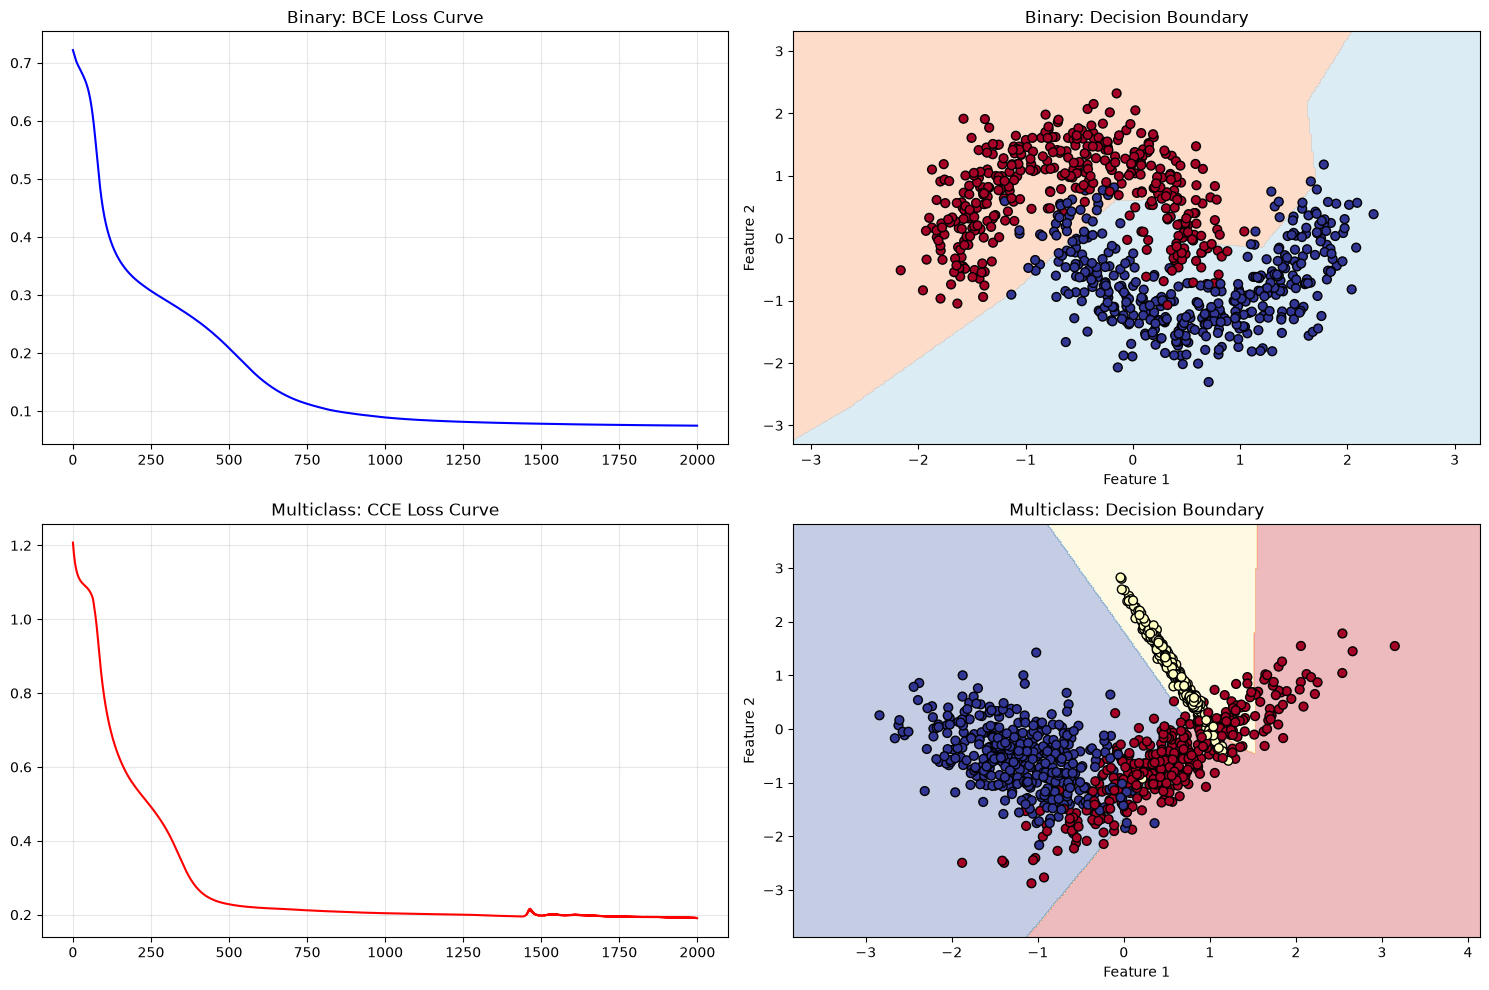

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 设置随机种子以保证结果可复现
torch.manual_seed(42)
np.random.seed(42)

# ============================================================
# 1. 模型定义：4层全连接神经网络
# ============================================================
class FourLayerNet(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        """
        input_dim: 输入特征数
        hidden_dims: 隐藏层神经元列表, 例如 [8, 6, 4]
        output_dim: 输出维度 (二分类为1, 多分类为类别数C)
        """
        super(FourLayerNet, self).__init__()
        
        # 定义网络层 (PyTorch的 nn.Linear 已经包含了权重W和偏置b)
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], hidden_dims[2])
        self.fc4 = nn.Linear(hidden_dims[2], output_dim)
        
        # 激活函数
        self.relu = nn.ReLU()
        
    def forward(self, x):
        """
        前向传播：PyTorch 会自动构建计算图，无需手动写 backward！
        注意：最后一层不加 Sigmoid/Softmax，直接输出 Logits！
        """
        x = self.relu(self.fc1(x))  # Layer 1
        x = self.relu(self.fc2(x))  # Layer 2
        x = self.relu(self.fc3(x))  # Layer 3
        x = self.fc4(x)             # Layer 4 (输出 Logits)
        return x

# ============================================================
# 2. 通用训练与评估函数
# ============================================================
def train_and_evaluate(model, X_train, y_train, X_test, y_test, 
                       task='binary', epochs=2000, lr=0.1, print_interval=400):
    
    # 将 NumPy 数组转换为 PyTorch 张量
    X_train_t = torch.FloatTensor(X_train)
    X_test_t = torch.FloatTensor(X_test)
    
    if task == 'binary':
        y_train_t = torch.FloatTensor(y_train).unsqueeze(1) # Shape: (m, 1)
        y_test_t = torch.FloatTensor(y_test).unsqueeze(1)
        # 关键：BCEWithLogitsLoss 内部自带 Sigmoid，数值更稳定
        criterion = nn.BCEWithLogitsLoss() 
    else:
        y_train_t = torch.LongTensor(y_train) # Shape: (m,) 多分类需要 LongTensor
        y_test_t = torch.LongTensor(y_test)
        # 关键：CrossEntropyLoss 内部自带 Softmax + Log
        criterion = nn.CrossEntropyLoss() 
        
    # 优化器：使用随机梯度下降 (SGD)，等价于手写的 W = W - lr * dW
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    losses = []
    
    print(f"🚀 开始训练 ({task} classification)...")
    for epoch in range(epochs):
        # --- 1. 前向传播 ---
        logits = model(X_train_t)
        
        # --- 2. 计算损失 ---
        loss = criterion(logits, y_train_t)
        losses.append(loss.item())
        
        # --- 3. 反向传播与参数更新 ---
        optimizer.zero_grad()  # 清空过往梯度 (PyTorch默认会累加梯度)
        loss.backward()        # 核心！自动计算所有参数的 .grad
        optimizer.step()       # 更新参数: W = W - lr * W.grad
        
        if (epoch + 1) % print_interval == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.6f}")
            
    # --- 评估 ---
    model.eval() # 切换到评估模式
    with torch.no_grad(): # 评估时不需要计算梯度
        test_logits = model(X_test_t)
        if task == 'binary':
            # Sigmoid 后大于 0.5 即为类别 1
            preds = (torch.sigmoid(test_logits) > 0.5).float()
            acc = (preds == y_test_t).float().mean().item() * 100
        else:
            # 取概率最大的索引作为预测类别
            preds = torch.argmax(test_logits, dim=1)
            acc = (preds == y_test_t).float().mean().item() * 100
            
    print(f"✅ 测试集准确率: {acc:.2f}%\n")
    model.train() # 切回训练模式
    return losses, model

# ============================================================
# 3. 辅助函数：绘制决策边界
# ============================================================
def plot_decision_boundary(model, X, y, scaler, title, task='binary'):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points_scaled = scaler.transform(grid_points)
    grid_tensor = torch.FloatTensor(grid_points_scaled)
    
    model.eval()
    with torch.no_grad():
        logits = model(grid_tensor)
        if task == 'binary':
            preds = (torch.sigmoid(logits) > 0.5).numpy().ravel()
        else:
            preds = torch.argmax(logits, dim=1).numpy()
            
    preds = preds.reshape(xx.shape)
    
    plt.contourf(xx, yy, preds, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k', s=40)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

# ============================================================
# 4. 运行实验
# ============================================================
if __name__ == "__main__":
    
    # ---------------- 实验 1：二分类 (Two Moons) ----------------
    print("=" * 60)
    print("实验 1：二分类任务")
    print("=" * 60)
    X_bin, y_bin = make_moons(n_samples=1000, noise=0.2, random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(X_bin, y_bin, test_size=0.2, random_state=42)
    
    scaler_bin = StandardScaler()
    X_tr = scaler_bin.fit_transform(X_tr)
    X_te = scaler_bin.transform(X_te)
    
    # 实例化模型：输入2 -> 隐藏层[8, 6, 4] -> 输出1
    model_bin = FourLayerNet(input_dim=2, hidden_dims=[8, 6, 4], output_dim=1)
    
    losses_bin, model_bin = train_and_evaluate(
        model_bin, X_tr, y_tr, X_te, y_te, task='binary', epochs=2000, lr=0.1
    )
    
    # ---------------- 实验 2：多分类 (3 Classes) ----------------
    print("=" * 60)
    print("实验 2：多分类任务")
    print("=" * 60)
    X_multi, y_multi = make_classification(
        n_samples=1500, n_features=2, n_informative=2, 
        n_redundant=0, n_classes=3, n_clusters_per_class=1, random_state=42
    )
    X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
    
    scaler_multi = StandardScaler()
    X_tr_m = scaler_multi.fit_transform(X_tr_m)
    X_te_m = scaler_multi.transform(X_te_m)
    
    # 实例化模型：输入2 -> 隐藏层[8, 6, 4] -> 输出3
    model_multi = FourLayerNet(input_dim=2, hidden_dims=[8, 6, 4], output_dim=3)
    
    losses_multi, model_multi = train_and_evaluate(
        model_multi, X_tr_m, y_tr_m, X_te_m, y_te_m, task='multiclass', epochs=2000, lr=0.1
    )
    
    # ---------------- 可视化 ----------------
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.plot(losses_bin, color='blue')
    plt.title('Binary: BCE Loss Curve')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 2)
    plot_decision_boundary(model_bin, X_tr, y_tr, scaler_bin, 'Binary: Decision Boundary', task='binary')
    
    plt.subplot(2, 2, 3)
    plt.plot(losses_multi, color='red')
    plt.title('Multiclass: CCE Loss Curve')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 4)
    plot_decision_boundary(model_multi, X_tr_m, y_tr_m, scaler_multi, 'Multiclass: Decision Boundary', task='multiclass')
    
    plt.tight_layout()
    plt.show()

In [19]:
import torch
import time

print("=" * 60)
print("🚀 GPU 版 PyTorch 全面测试")
print("=" * 60)

# ==================== 1. 基础信息 ====================
print("\n【1. 基础信息】")
print(f"PyTorch 版本: {torch.__version__}")

# ==================== 2. CUDA 可用性检测（核心） ====================
print("\n【2. CUDA 检测（核心）】")
cuda_available = torch.cuda.is_available()
print(f"CUDA 是否可用: {cuda_available}")

if not cuda_available:
    print("❌ CUDA 不可用！请检查：")
    print("   1. 是否有 NVIDIA 独立显卡")
    print("   2. 显卡驱动是否安装且支持 CUDA")
    print("   3. 安装的 PyTorch 版本是否与驱动匹配")
    print("\n   当前驱动支持的 CUDA 版本可通过 nvidia-smi 查看")
else:
    print(f"✅ CUDA 版本: {torch.version.cuda}")
    print(f"✅ cuDNN 版本: {torch.backends.cudnn.version()}")
    print(f"✅ GPU 数量: {torch.cuda.device_count()}")
    print(f"✅ 当前 GPU 名称: {torch.cuda.get_device_name(0)}")
    print(f"✅ 当前 GPU 显存总量: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

# ==================== 3. 张量运算测试 ====================
print("\n【3. 张量运算测试】")

# CPU 张量运算
cpu_start = time.time()
cpu_tensor = torch.rand(1000, 1000)
cpu_result = cpu_tensor @ cpu_tensor.T  # 矩阵乘法
cpu_time = time.time() - cpu_start
print(f"CPU 张量运算耗时: {cpu_time:.4f} 秒")

# GPU 张量运算（如果可用）
if cuda_available:
    gpu_start = time.time()
    gpu_tensor = torch.rand(1000, 1000).cuda()
    gpu_result = gpu_tensor @ gpu_tensor.T
    # 强制同步等待 GPU 计算完成，确保时间准确
    torch.cuda.synchronize()
    gpu_time = time.time() - gpu_start
    print(f"GPU 张量运算耗时: {gpu_time:.4f} 秒")
    print(f"加速比: {cpu_time / gpu_time:.2f} 倍")

# ==================== 4. 自动求导测试（GPU 版） ====================
if cuda_available:
    print("\n【4. GPU 自动求导测试】")
    try:
        x = torch.tensor(2.0, requires_grad=True, device="cuda")
        y = x ** 2 + 3 * x + 1
        y.backward()
        print(f"✅ GPU 自动求导正常: x=2.0, dy/dx={x.grad.item():.1f} (预期 7.0)")
    except Exception as e:
        print(f"❌ GPU 自动求导失败: {e}")

# ==================== 5. 显存管理测试 ====================
if cuda_available:
    print("\n【5. 显存管理测试】")
    # 分配 100MB 显存并释放，测试显存管理是否正常
    test_tensor = torch.rand(1024, 1024 * 100, device="cuda")  # 约 100MB
    before = torch.cuda.memory_allocated() / 1024**3
    print(f"分配后显存占用: {before:.2f} GB")
    del test_tensor
    torch.cuda.empty_cache()
    after = torch.cuda.memory_allocated() / 1024**3
    print(f"释放后显存占用: {after:.2f} GB")
    print("✅ 显存分配与释放正常")

# ==================== 6. 最终结论 ====================
print("\n" + "=" * 60)
if cuda_available:
    print("🎉 恭喜！GPU 版 PyTorch 已完全就绪，可以开始模型训练！")
else:
    print("⚠️ 当前 PyTorch 运行在 CPU 模式。如需 GPU 加速：")
    print("   1. 检查显卡驱动：nvidia-smi")
    print("   2. 确认 PyTorch 安装版本是否正确")
    print("   3. 尝试重新安装匹配 CUDA 版本的 PyTorch")
print("=" * 60)

🚀 GPU 版 PyTorch 全面测试

【1. 基础信息】
PyTorch 版本: 2.5.1+cu121

【2. CUDA 检测（核心）】
CUDA 是否可用: True
✅ CUDA 版本: 12.1
✅ cuDNN 版本: 90100
✅ GPU 数量: 1
✅ 当前 GPU 名称: NVIDIA GeForce RTX 4060 Laptop GPU
✅ 当前 GPU 显存总量: 8.00 GB

【3. 张量运算测试】
CPU 张量运算耗时: 0.0065 秒
GPU 张量运算耗时: 0.2536 秒
加速比: 0.03 倍

【4. GPU 自动求导测试】
✅ GPU 自动求导正常: x=2.0, dy/dx=7.0 (预期 7.0)

【5. 显存管理测试】
分配后显存占用: 0.41 GB
释放后显存占用: 0.02 GB
✅ 显存分配与释放正常

🎉 恭喜！GPU 版 PyTorch 已完全就绪，可以开始模型训练！
